# Wasserstein DRO as a geometric ambiguity set

This notebook generates `fig:kantorovich-dro-ambiguity`. It illustrates the Wasserstein distributionally robust objective

$$
    \sup_{\beta:\, W_p(\beta,\hat\alpha_n)\leq \rho}
    \int \ell_\theta(z)\,d\beta(z)
$$

as a spatial perturbation picture. The empirical law is a red point cloud. A Wasserstein ambiguity set allows the adversary to transport empirical mass within a global budget; visually, small local disks suggest the possible perturbation directions around each atom. We do not solve a full DRO problem here. Instead, we move atoms along one fixed loss-gradient direction and allocate a finite transport budget to the atoms closest to a linear decision boundary, which is the geometric content of the inner adversarial perturbation in the dual formula.

The exported PDF panels contain no titles; LaTeX supplies the panel labels and caption.

In [1]:
from pathlib import Path
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate figure_style.py")

sys.path.insert(0, str(FIGROOT.resolve()))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.colors import to_rgb

from figure_style import (
    BACKGROUND,
    BLUE,
    DIRAC_MARKER_SIZE,
    GRAY,
    RED,
    VIOLET,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "kantorovich-dro-ambiguity"
OUT = figure_dir(NAME)
ARXIV_OUT = ROOT / "arxiv" / "figures"
THUMB_OUT = FIGROOT / "thumbnails"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)
THUMB_OUT.mkdir(parents=True, exist_ok=True)


## Empirical cloud, classifier, and adversarial direction

The points are deliberately placed mostly on one side of a linear decision boundary

$$
    \langle w,z\rangle = \tau.
$$

For this positive-class cartoon, the loss increases in the normal direction $w/\|w\|$, so moving atoms along this direction pushes them toward the boundary and then into the high-loss side. The budgeted perturbation below sorts the atoms by margin and moves the closest atoms first. This is only a visual proxy for the inner supremum, but it keeps the geometry honest: the perturbation is a transport of mass, not a change of labels or weights.

In [2]:
rng = np.random.default_rng(2407)

n1, n2 = 17, 11
cloud1 = rng.normal(size=(n1, 2)) @ np.array([[0.25, 0.08], [0.00, 0.16]]) + np.array([-0.72, 0.16])
cloud2 = rng.normal(size=(n2, 2)) @ np.array([[0.18, -0.06], [0.02, 0.18]]) + np.array([-0.22, -0.34])
z = np.vstack([cloud1, cloud2])
n = len(z)

w = np.array([1.0, 0.38])
w = w / np.linalg.norm(w)
tau = 0.02
safe_margin = tau - z @ w

grad = w.copy()
local_radius = 0.22
max_step = 0.24
rho = 0.075  # average displacement budget per atom in this display
remaining = rho * n
steps = np.zeros(n)
for i in np.argsort(safe_margin):
    if remaining <= 1e-12:
        break
    # Spend budget on atoms closest to the boundary, with a small overshoot.
    wanted = np.clip(safe_margin[i] + 0.045, 0.0, max_step)
    step = min(wanted, remaining)
    steps[i] = step
    remaining -= step

z_shift = z + steps[:, None] * grad
print(f"n={n}, average displacement={steps.mean():.3f}, total budget used={steps.sum():.3f}, remaining={remaining:.3e}")
print(f"moved atoms={np.sum(steps > 1e-12)}, max step={steps.max():.3f}")


n=28, average displacement=0.075, total budget used=2.100, remaining=0.000e+00
moved atoms=10, max step=0.240


## Drawing utilities

The three panels share the same coordinate window. A very light blue half-plane indicates the high-loss side of the classifier, while the red empirical atoms remain the reference measure. The perturbation arrows are purple, and the transported adversarial atoms use a red-to-blue interpolation according to the amount of displacement.

In [3]:
all_points = np.vstack([z, z_shift])
margin = 0.30
xlim = (all_points[:, 0].min() - margin, all_points[:, 0].max() + margin)
ylim = (all_points[:, 1].min() - margin, all_points[:, 1].max() + margin)
# Keep enough room for the loss-gradient arrow.
xlim = (min(xlim[0], -1.38), max(xlim[1], 0.70))
ylim = (min(ylim[0], -0.90), max(ylim[1], 0.86))


def boundary_points():
    xs = np.linspace(xlim[0] - 0.2, xlim[1] + 0.2, 256)
    if abs(w[1]) > 1e-12:
        ys = (tau - w[0] * xs) / w[1]
        mask = (ys >= ylim[0] - 0.2) & (ys <= ylim[1] + 0.2)
        return xs[mask], ys[mask]
    ys = np.linspace(ylim[0], ylim[1], 256)
    xs = np.full_like(ys, tau / w[0])
    return xs, ys


def draw_background(ax):
    ax.set_facecolor(BACKGROUND)
    gx = np.linspace(xlim[0], xlim[1], 160)
    gy = np.linspace(ylim[0], ylim[1], 160)
    X, Y = np.meshgrid(gx, gy)
    score = w[0] * X + w[1] * Y - tau
    ax.contourf(X, Y, score, levels=[0, score.max() + 1], colors=["#e7f0fa"], alpha=0.66, zorder=0)
    bx, by = boundary_points()
    ax.plot(bx, by, color="#2b2b2b", lw=0.95, ls=(0, (4.0, 2.2)), zorder=4)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    remove_axes(ax)


def draw_loss_arrow(ax, *, anchor=np.array([-1.20, 0.63]), length=0.42, alpha=0.92):
    end = anchor + length * grad
    arr = FancyArrowPatch(
        anchor, end, arrowstyle="-|>", mutation_scale=10.0, color=VIOLET,
        lw=1.05, alpha=alpha, zorder=8, shrinkA=0.0, shrinkB=0.0,
    )
    ax.add_patch(arr)
    ax.text(end[0] + 0.02, end[1] + 0.01, r"$\nabla_z\ell$", color=VIOLET, fontsize=8, zorder=9)


def draw_empirical_points(ax, *, alpha=1.0, size_factor=0.88, zorder=6):
    ax.scatter(z[:, 0], z[:, 1], s=DIRAC_MARKER_SIZE * size_factor, color=RED, edgecolor="none", alpha=alpha, zorder=zorder)


def draw_disks(ax):
    for p in z:
        ax.add_patch(Circle(p, local_radius, facecolor="#d7302708", edgecolor="#d730274d", lw=0.52, zorder=2))


def draw_shift_arrows(ax):
    moved = steps > 1e-12
    segments = [[z[i], z_shift[i]] for i in np.where(moved)[0]]
    if segments:
        widths = 0.34 + 1.12 * steps[moved] / max(steps.max(), 1e-12)
        base = np.array(to_rgb(VIOLET))
        colors = [(*base, 0.50 + 0.35 * s / max(steps.max(), 1e-12)) for s in steps[moved]]
        lc = LineCollection(segments, colors=colors, linewidths=widths, zorder=5, capstyle="round")
        ax.add_collection(lc)
        for i in np.where(moved)[0]:
            start = z[i] + 0.72 * (z_shift[i] - z[i])
            end = z_shift[i]
            ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=6.0, lw=0.0, color=VIOLET, alpha=0.70, zorder=6))


def draw_shifted_points(ax):
    moved = steps > 1e-12
    colors = [interp_color(min(s / max(steps.max(), 1e-12), 1.0), RED, BLUE) for s in steps[moved]]
    ax.scatter(z_shift[moved, 0], z_shift[moved, 1], s=DIRAC_MARKER_SIZE * 0.82, color=colors, edgecolor="none", zorder=7)
    # Unmoved atoms remain faint to show that a global budget does not perturb every sample.
    ax.scatter(z[~moved, 0], z[~moved, 1], s=DIRAC_MARKER_SIZE * 0.50, color=RED, edgecolor="none", alpha=0.32, zorder=5)


def draw_panel(kind, path, *, thumbnail=False):
    fig, ax = plt.subplots(figsize=(2.25, 2.05))
    draw_background(ax)
    if kind == "empirical-cloud":
        draw_empirical_points(ax)
        draw_loss_arrow(ax)
    elif kind == "ambiguity-disks":
        draw_disks(ax)
        draw_empirical_points(ax)
        draw_loss_arrow(ax, alpha=0.75)
    elif kind == "worst-case-shift":
        draw_disks(ax)
        draw_empirical_points(ax, alpha=0.35, size_factor=0.72, zorder=4)
        draw_shift_arrows(ax)
        draw_shifted_points(ax)
        draw_loss_arrow(ax, alpha=0.75)
    else:
        raise ValueError(kind)
    save_pdf(fig, path, pad_inches=0.035)
    plt.close(fig)

for kind in ["empirical-cloud", "ambiguity-disks", "worst-case-shift"]:
    draw_panel(kind, OUT / f"{kind}.pdf")
    shutil.copyfile(OUT / f"{kind}.pdf", ARXIV_OUT / f"{NAME}--{kind}.pdf")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


...

'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Thumbnail

The thumbnail is a compact raster contact sheet of the three exported panels. It is used by the searchable figure gallery and by GitHub's notebook preview.

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.25))
for ax, kind in zip(axes, ["empirical-cloud", "ambiguity-disks", "worst-case-shift"]):
    draw_background(ax)
    if kind == "empirical-cloud":
        draw_empirical_points(ax)
        draw_loss_arrow(ax)
    elif kind == "ambiguity-disks":
        draw_disks(ax)
        draw_empirical_points(ax)
        draw_loss_arrow(ax, alpha=0.75)
    else:
        draw_disks(ax)
        draw_empirical_points(ax, alpha=0.35, size_factor=0.72, zorder=4)
        draw_shift_arrows(ax)
        draw_shifted_points(ax)
        draw_loss_arrow(ax, alpha=0.75)
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.02, top=0.98, wspace=0.05)
thumb_path = THUMB_OUT / f"{NAME}.png"
fig.savefig(thumb_path, dpi=190, bbox_inches="tight", pad_inches=0.015)
plt.close(fig)


## Figure preview

The output below embeds the generated thumbnail so the notebook renders directly on GitHub.

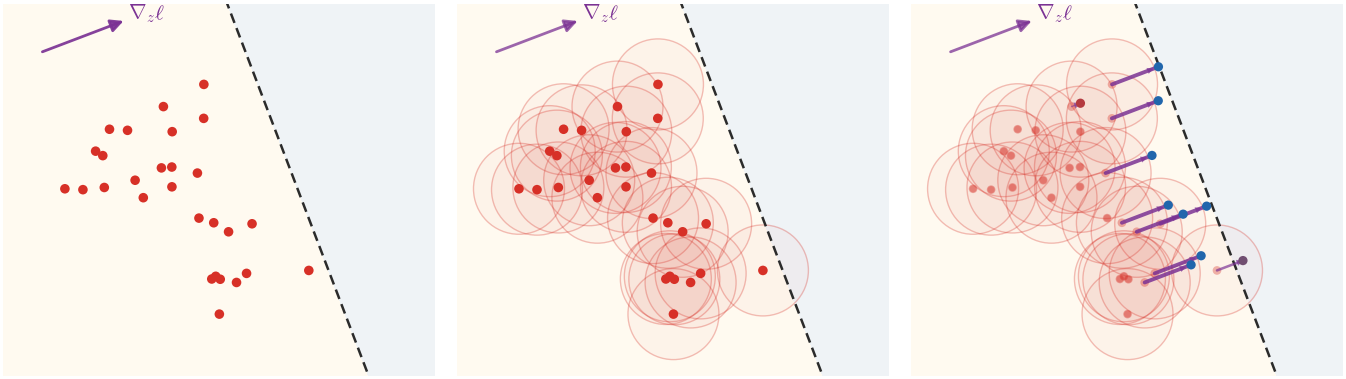

In [5]:
from IPython.display import Image, display

preview = THUMB_OUT / f"{NAME}.png"
display(Image(filename=str(preview)))
